# 1. Defining the Problem.

We shall be solving the heat equation :

$$ u_t = \alpha u_{xx} $$

with the boundary conditions :

$$ u(0,t) = u(1,t) = 0 $$

For this we shall be fixing $\alpha = 0.1$ and generating many sets of initial conditions.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
torch.manual_seed(17)

# 2. Generating Data.

We shall be generating the initial conditions using the following recipe :

$$ u(x,0) = a(x) = \sum_{n=1}^{N_{modes}} A_n\sin(n\pi x) $$

where $ A_n \in \mathcal{U}(-1,1) $.

Further, the exact solutions corresponding to these initial conditions are :

$$ u(x,t) = \sum_{n=1}^{N_{modes}} A_n e^{-\alpha n^2\pi^2 t} \sin(n\pi x) $$

In [2]:
# constants and parameters
pi = torch.pi
alpha = 0.1
N_train = 1000
N_test = 200
N_modes = 20
N_x, N_t = 81,61
x_arr = torch.linspace(0.0,1.0,N_x)
t_arr = torch.linspace(0.0,1.0,N_t)

In [3]:
def input_output_functions(N_func, x_arr, t_arr, N_x, N_t, N_modes, A_coeff):
    x_mesh, t_mesh = torch.meshgrid(x_arr, t_arr,indexing='ij')
    input_points = torch.column_stack((x_mesh.flatten(),t_mesh.flatten()))
    a = torch.zeros((N_func,N_x))               # initial condition functions
    u = torch.zeros(N_func,N_x * N_t)      # complete solutions of all input functions
    for n in range(N_modes):
        a += torch.outer(A_coeff[:,n], torch.sin((n+1)*pi*x_arr))
        u += torch.outer(A_coeff[:,n], ((torch.exp(-alpha * pi**2 * (n+1)**2 * t_mesh) * torch.sin((n+1) * pi * x_mesh))).flatten())
    return a, u.reshape(N_func, N_x, N_t)

In [4]:
# testing the input-output generating function
a_test, u_test = input_output_functions(
    N_func=3,
    x_arr = x_arr,
    t_arr = t_arr,
    N_x = N_x,
    N_t = N_t,
    N_modes = 3,
    A_coeff = torch.tensor([[1.0, 0.0, 0.0],[0.0, 1.0, 0.0], [0.5, 0.7, 0.4]])
)

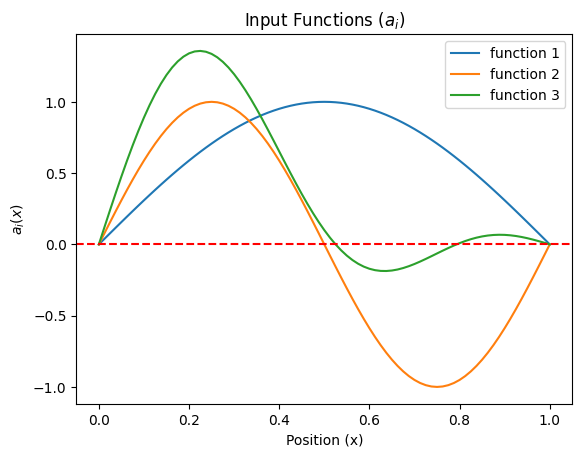

In [5]:
# visualisation
# input functions
plt.plot(x_arr, a_test[0],label = 'function 1')
plt.plot(x_arr, a_test[1],label = 'function 2')
plt.plot(x_arr, a_test[2],label = 'function 3')
plt.axhline(0,c='red',ls = '--')
plt.title('Input Functions ($a_i$)')
plt.legend()
plt.xlabel('Position (x)')
plt.ylabel("$a_i(x)$")
plt.show()

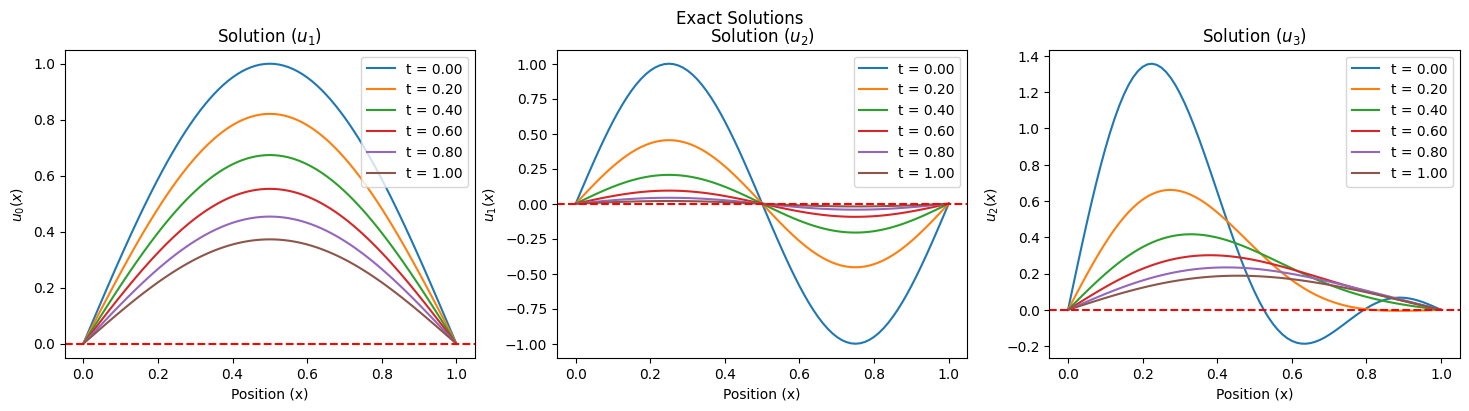

In [6]:
# visualisation
# output functions
plt.figure(figsize = (18,4))

for i in range(3):
    plt.subplot(1,3,i+1)
    N_times = 5
    base_index = int((N_t - 1)/N_times)
    for j in range(N_times + 1):
        plt.plot(x_arr, u_test[i,:, base_index * j],label = f't = {t_arr[base_index * j]:.02f}')
    plt.axhline(0,c='red',ls = '--')
    plt.title(f'Solution ($u_{i+1}$)')
    plt.legend()
    plt.xlabel('Position (x)')
    plt.ylabel(f"$u_{i}(x)$")
plt.suptitle("Exact Solutions")
plt.show()

Testing went good for data generating functions. Next we shall generate the data.

In [7]:
A_coeff_train = 2 * torch.rand((N_train, N_modes)) - 1
A_coeff_test = 2 * torch.rand((N_test, N_modes)) - 1
a_train, u_train = input_output_functions(N_train, x_arr, t_arr, N_x, N_t, N_modes, A_coeff_train)
a_test, u_test = input_output_functions(N_test, x_arr, t_arr, N_x, N_t, N_modes, A_coeff_test)

print("Data Shape Summary :\n")
print(f"Input Training Data : {a_train.shape}")
print(f"Solutions Training Data : {u_train.shape}")
print(f"Input Testing Data : {a_test.shape}")
print(f"Solutions Testing Data : {u_test.shape}")

Data Shape Summary :

Input Training Data : torch.Size([1000, 81])
Solutions Training Data : torch.Size([1000, 81, 61])
Input Testing Data : torch.Size([200, 81])
Solutions Testing Data : torch.Size([200, 81, 61])


# 3. Normalizing the Data.

In [8]:
# processing the training data
# Normalize a_train
a_mean = torch.mean(a_train)
a_std  = torch.std(a_train)
a_train_norm = (a_train - a_mean) / a_std

# Normalize x coordinates
x_mean = torch.mean(x_arr)
x_std  = torch.std(x_arr)
x_arr_norm = (x_arr - x_mean) / x_std

# Repeat x for every sample
x_train_norm = x_arr_norm.unsqueeze(0).repeat(a_train.shape[0], 1)
# shape: (2, 3)

# Combine into input tensor
input_train_data = torch.stack((a_train_norm, x_train_norm), dim=-1)
# shape: (2, 3, 2)

print(input_train_data.shape)

torch.Size([1000, 81, 2])


In [9]:
# processing the testing data
# Normalize a_test
a_test_norm = (a_test - a_mean) / a_std

# Repeat x for every sample
x_test_norm = x_arr_norm.unsqueeze(0).repeat(a_test.shape[0], 1)
# shape: (2, 3)

# Combine into input tensor
input_test_data = torch.stack((a_test_norm, x_test_norm), dim=-1)
# shape: (2, 3, 2)

print(input_test_data.shape)

torch.Size([200, 81, 2])


# 4. Lifting the Input Features.

We shall have our inputs in the format : $[a(x), x]$

For example, suppose that we are choosing $N_x = 3$ with $x_arr = [0.0, 0.5, 1.0]$. Also assume that there are just 2 training functions, i.e. $N_{\text{train}} = 2$, then the input training data will look like :

$ [[[a_1(0.0),0.0],\\
[a_1(0.5), 0.5],\\
[a_1(1.0), 1.0]],\\
[[a_2(0.0),0.0],\\
[a_2(0.5), 0.5],\\
[a_2(1.0), 1.0]]]$

making the shape : (2,3,2)

In general, we have train_data.shape : $(N_{\text{train}}, N_x, 2)$ for the current problem. We want use a linear MLP layer to project the data $[a(x),x]$ onto a higher dimensional latent space. For this, notebook we shall be using latent_dim = 64. Thus after lifting, the $(N_{\text{train}}, N_x, 2)$ shaped data becomes $(N_{\text{train}}, N_x, \text{latent\_dim)}$.

In [10]:
# lifting function
def lifting_test(input_data, latent_dim):
    model = nn.Linear(2,latent_dim)
    return model(input_data)

# this itself is just a test function. The actual lifting will be defined inside the FNO model class

In [11]:
# testing the lifting function
lifting_test_tensor = torch.tensor([[[1,2], [3,4], [5,6]], [[1,2], [3,4], [5,6]]], dtype=torch.float)
lifting_test_output = lifting_test(lifting_test_tensor, 4)
print(f'{lifting_test_tensor.shape}\n\n{lifting_test_tensor}')
print(f'\n\n{lifting_test_output.shape}\n\n{lifting_test_output}')

torch.Size([2, 3, 2])

tensor([[[1., 2.],
         [3., 4.],
         [5., 6.]],

        [[1., 2.],
         [3., 4.],
         [5., 6.]]])


torch.Size([2, 3, 4])

tensor([[[-0.3179,  2.0305, -0.9220, -1.6601],
         [-0.4870,  4.2148, -1.4697, -4.1529],
         [-0.6561,  6.3991, -2.0174, -6.6457]],

        [[-0.3179,  2.0305, -0.9220, -1.6601],
         [-0.4870,  4.2148, -1.4697, -4.1529],
         [-0.6561,  6.3991, -2.0174, -6.6457]]], grad_fn=<ViewBackward0>)


# 5. FNO Block.

FNO block lies at the heart of the architecture. The equation can be bluntly stated as :

$$ v_{l+1}(x) = \sigma(W_lv_l(x) + \mathcal{F}^{-1}[R_l \mathcal{F}[v_l]](x)) $$

It can be thought as having two sub-blocks running in parallel. These are :

## 5.1. The Fourier Layer/ Spectral Layer.

#### (Captures the Global Structure in the data)

This layer helps understand the global structure of the data using FFT. For quick overview, this layer does the following (carrying forward the same example as in the lifting layer) :

--> Take rFFT of the lifted data (shape : (2,3,4)) interpreting columns as spatial data

--> We obtain (shape : 2,2,4)

--> apply matrix multiplication to each of the 4 channels

--> When latent_dim is large (say 64), we may safely reject higher frequency modes in rfft. The reason for this is due to simple assumption that ODE/PDE solutions are smooth enough. Further, these high frequency modes capture the more local behaviour of the solutions, which we shall see in the next subsection, is captured by the linear layer.

--> To reject the higher modes, we simply set them to zero. Thus, the shape remains : (2,3,4)

--> Take irfft on this data to get back the shape : (2,3,4)

Taking more general numbers, the shape in this layer follows as :

--> lifted layer : $(\text{N\_batch}, N_x, \text{latent\_dim})$

--> after rfft : $(\text{N\_batch}, N_x//2+1, \text{latent\_dim})$

--> channel-wise mat. multiplication : $(\text{N\_batch}, N_x//2 + 1, \text{latent\_dim})$

--> irfft : $(\text{N\_batch}, N_x, \text{latent\_dim})$

Note that the matrices in the mat. multiplication are square matrices of the same order : $\text{latent\_dim} \times \text{latent\_dim}$.

## 5.2. The Linear Layer.

#### (Captures the Local Structure in the data)

This part is simpler. It is just a linear matrix multiplied to capture the more local structure of the data.

## 5.3. Clubbing the two layers together.

Post this, the results of both the layers are of same dimensions and are added and passed through an activation function to complete a single FNO block. Multiple such blocks (3 in this notebook) are implemented in sequence for better learning.

# 6. Projection.

After FNO blocks, the shape stays : $(\text{N\_batch}, N_x, \text{latent\_dim})$. Since, we want predictions at each time stamps, we shall use a linear layer to obtain the final output shape : $(\text{N\_batch}, N_x, N_t)$.

In [12]:
# fourier layer in an FNO Block
class Fourier_Layer(nn.Module):
    def __init__(self, n_modes, latent_dim):
        super().__init__()

        self.n_modes = n_modes
        self.latent_dim = latent_dim

        scale = 1/latent_dim
        self.weights = nn.Parameter(scale * torch.rand(n_modes, latent_dim, latent_dim, dtype = torch.cfloat))            # the weights are complex because the corresponding matrices act in the fourier space

    def forward(self, x_lifted):
        # x_lifted.shape : (N_batch, N_x, latent_dim)
        # taking fft
        x_rfft = torch.fft.rfft(x_lifted, dim = 1)

        # x_rfft.shape : (N_batch, N_x//2 + 1, latent_dim)
        # multipying the kernel functions
        # note that n_modes should be less than or equal to N_x//2 + 1
        x_rfft_kernel_multiplied = torch.zeros_like(x_rfft)
        x_rfft_kernel_multiplied[:,:self.n_modes,:] += torch.einsum("bmi,mio->bmo", x_rfft[:,:self.n_modes,:], self.weights)

        # taking inverse fft
        x_irfft = torch.fft.irfft(x_rfft_kernel_multiplied, dim = 1, n = x_lifted.shape[1])
        # x_irfft.shape : (N_batch, N_x, latent_dim)

        return x_irfft

In [13]:
# Single FNO Block
class FNO_block(nn.Module):
    def __init__(self, latent_dim, n_modes):
        super().__init__()
        self.Fourier_Layer = Fourier_Layer(n_modes, latent_dim)
        self.Linear_Layer = nn.Linear(latent_dim, latent_dim)
        self.activation = nn.GELU()

    def forward(self,x_lifted):
        return self.activation(self.Fourier_Layer(x_lifted) + self.Linear_Layer(x_lifted))

In [14]:
# Complete FNO model architecture
class FNO(nn.Module):
    def __init__(self, latent_dim, n_modes, N_FNO_blocks,N_t):
        super().__init__()

        self.Lifting_Layer = nn.Linear(2, latent_dim)
        self.FNO_Blocks = nn.ModuleList([FNO_block(latent_dim, n_modes) for _ in range(N_FNO_blocks)])
        self.Projection_Layer = nn.Linear(latent_dim,N_t)

    def forward(self,x):
        # lifting the input data
        x = self.Lifting_Layer(x)

        # passing lifted data through <N_FNO_blocks> no. of FNO blocks
        for block in self.FNO_Blocks:
            x = block(x)

        # projection
        x = self.Projection_Layer(x)

        return x

In [15]:
model = FNO(latent_dim=64, n_modes=5, N_FNO_blocks=3, N_t = N_t)

# Defining the Loss function
def Loss(model, x_input, u_true):
    u_pred = model(x_input)

    loss = torch.mean((u_pred - u_true)**2)
    return loss

In [16]:
# defining the optimizers
adam_optim = torch.optim.Adam(model.parameters(), lr = 0.001)
lbfgs_optim = torch.optim.LBFGS(model.parameters(), lr = 1.0, max_iter=1500, max_eval=1500, tolerance_grad=10**-10, tolerance_change=10**-14, line_search_fn="strong_wolfe")

In [17]:
# training the model using Adam optimizer
N_epochs = 200
adam_loss_arr = []

print(f"Training using using Adam optimizer started for {N_epochs} epochs ...")
for epoch in range(N_epochs):
    adam_optim.zero_grad()
    loss = Loss(model, input_train_data, u_train)
    adam_loss_arr.append(loss.item())
    loss.backward()
    adam_optim.step()
    if epoch % int(N_epochs/10) == 0:
            print(f"Epoch : {epoch} | loss = {loss.item():.6e}")
print("Training using using Adam optimizer finished.\n")

Training using using Adam optimizer started for 200 epochs ...
Epoch : 0 | loss = 1.649079e-01
Epoch : 20 | loss = 6.828815e-02
Epoch : 40 | loss = 1.682220e-02
Epoch : 60 | loss = 6.013796e-03
Epoch : 80 | loss = 2.614619e-03
Epoch : 100 | loss = 1.561288e-03
Epoch : 120 | loss = 1.112655e-03
Epoch : 140 | loss = 8.866891e-04
Epoch : 160 | loss = 7.590092e-04
Epoch : 180 | loss = 6.649664e-04
Training using using Adam optimizer finished.



In [18]:
# using lbfgs optimizer
lbfgs_loss_arr = []
print("Training using using LBFGS optimizer started ...")
def closure():
    lbfgs_optim.zero_grad()
    loss = Loss(model, input_train_data, u_train)
    lbfgs_loss_arr.append(loss.item())
    loss.backward()
    return loss

lbfgs_optim.step(closure)
print("Training using using LBFGS optimizer finished.")
print(f"Final L-BFGS loss: {lbfgs_loss_arr[-1]:.6e}")

Training using using LBFGS optimizer started ...
Training using using LBFGS optimizer finished.
Final L-BFGS loss: 4.296328e-05


In [19]:
print(u_train.min().item(), u_train.max().item())
print(u_train.mean().item(), u_train.std().item())

-7.025630950927734 6.943647861480713
-0.0051341187208890915 0.39983123540878296


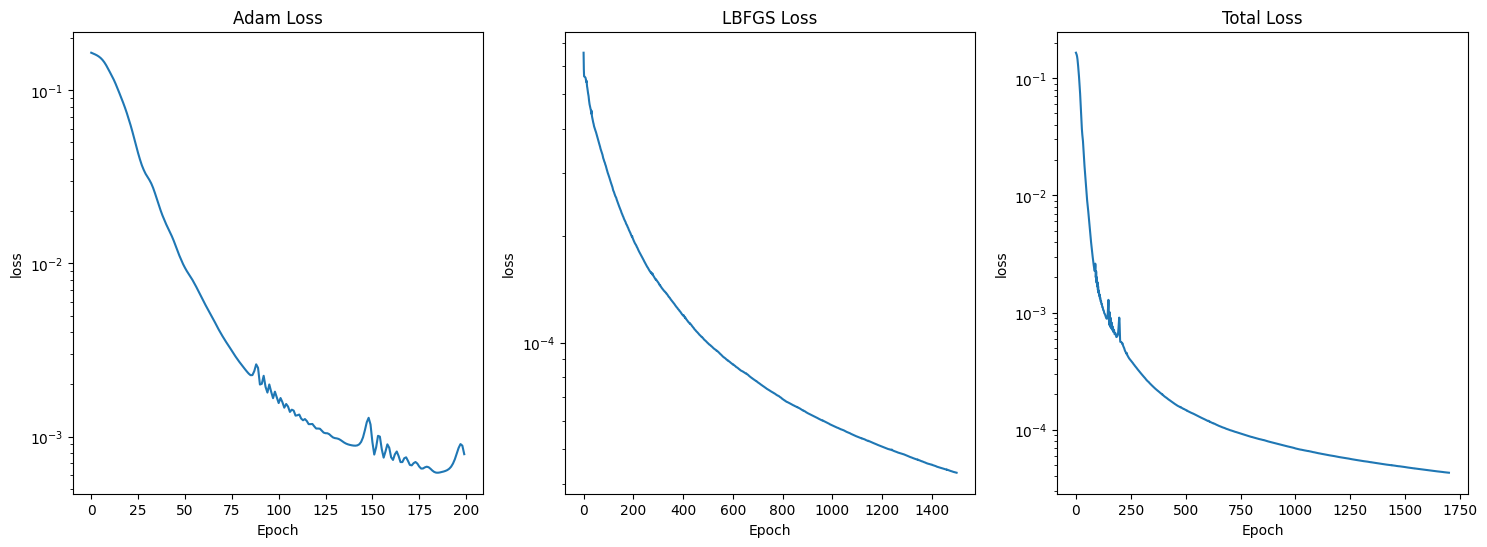

In [20]:
# visualing the loss
plt.figure(figsize = (18,6))

plt.subplot(1,3,1)
plt.semilogy(adam_loss_arr)
plt.title("Adam Loss")
plt.xlabel("Epoch")
plt.ylabel("loss")

plt.subplot(1,3,2)
plt.semilogy(lbfgs_loss_arr)
plt.title("LBFGS Loss")
plt.xlabel("Epoch")
plt.ylabel("loss")

plt.subplot(1,3,3)
plt.semilogy(adam_loss_arr + lbfgs_loss_arr)
plt.title("Total Loss")
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.show()

In [21]:
model.eval()

with torch.no_grad():
    u_test_pred = model(input_test_data)

    test_mse = torch.mean((u_test_pred - u_test) ** 2)
    test_rmse = torch.sqrt(test_mse)

print("Test MSE :", test_mse.item())
print("Test RMSE:", test_rmse.item())

Test MSE : 4.459401316125877e-05
Test RMSE: 0.006677874829620123


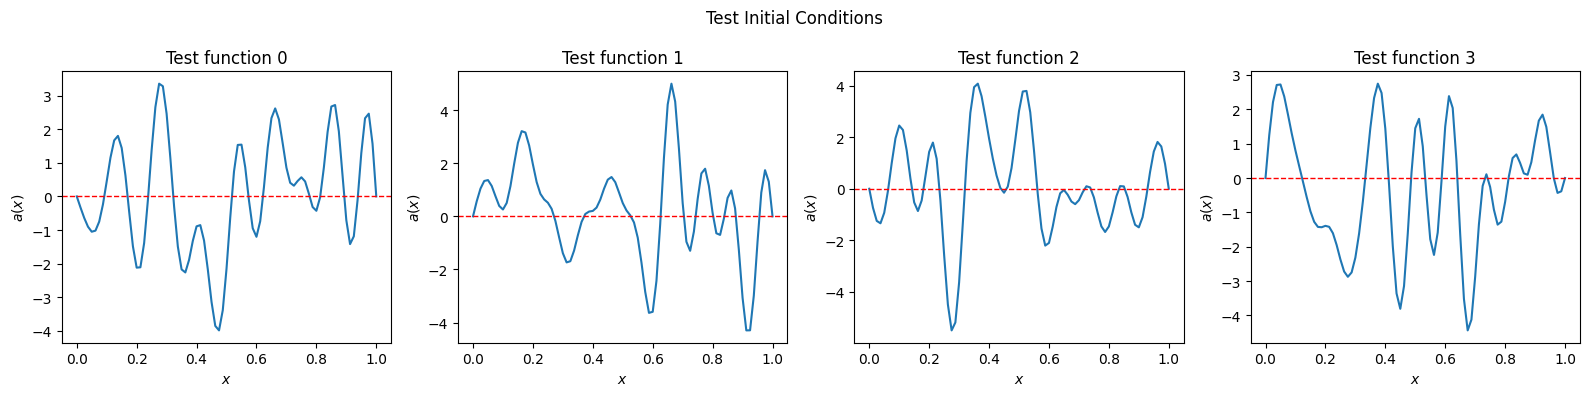

In [22]:
function_indices = [0, 1, 2, 3]

plt.figure(figsize=(16, 4))

for plot_index, function_index in enumerate(function_indices):
    plt.subplot(1, 4, plot_index + 1)

    plt.plot(x_arr.detach().cpu().numpy(),a_test[function_index].detach().cpu().numpy())

    plt.axhline(0.0, color="red", linestyle="--", linewidth=1)

    plt.xlabel(r"$x$")
    plt.ylabel(r"$a(x)$")
    plt.title(f"Test function {function_index}")

plt.suptitle("Test Initial Conditions")
plt.tight_layout()
plt.show()

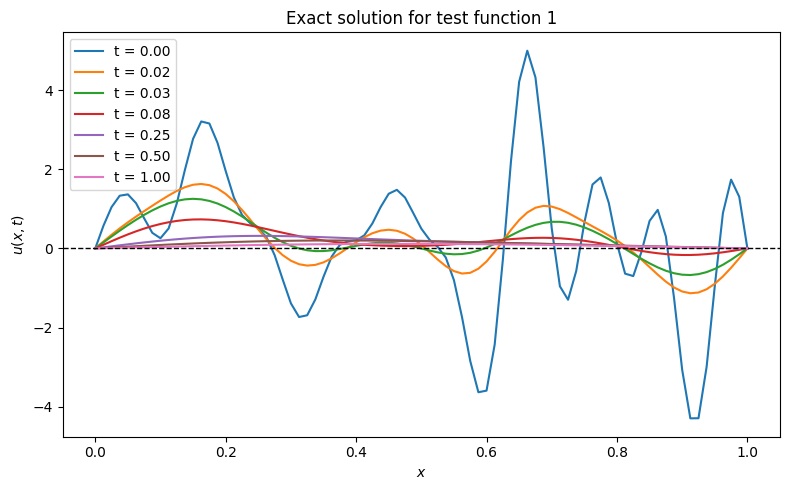

In [23]:
function_index = 1

time_indices = [0,1,2,5,15,30,60]

plt.figure(figsize=(8, 5))

for time_index in time_indices:
    plt.plot(x_arr.detach().cpu().numpy(),u_test[function_index,:,time_index].detach().cpu().numpy(), label=f"t = {t_arr[time_index].item():.2f}")

plt.axhline(0.0,color="black",linestyle="--",linewidth=1)

plt.xlabel(r"$x$")
plt.ylabel(r"$u(x,t)$")
plt.title(f"Exact solution for test function {function_index}")
plt.legend()
plt.tight_layout()
plt.show()

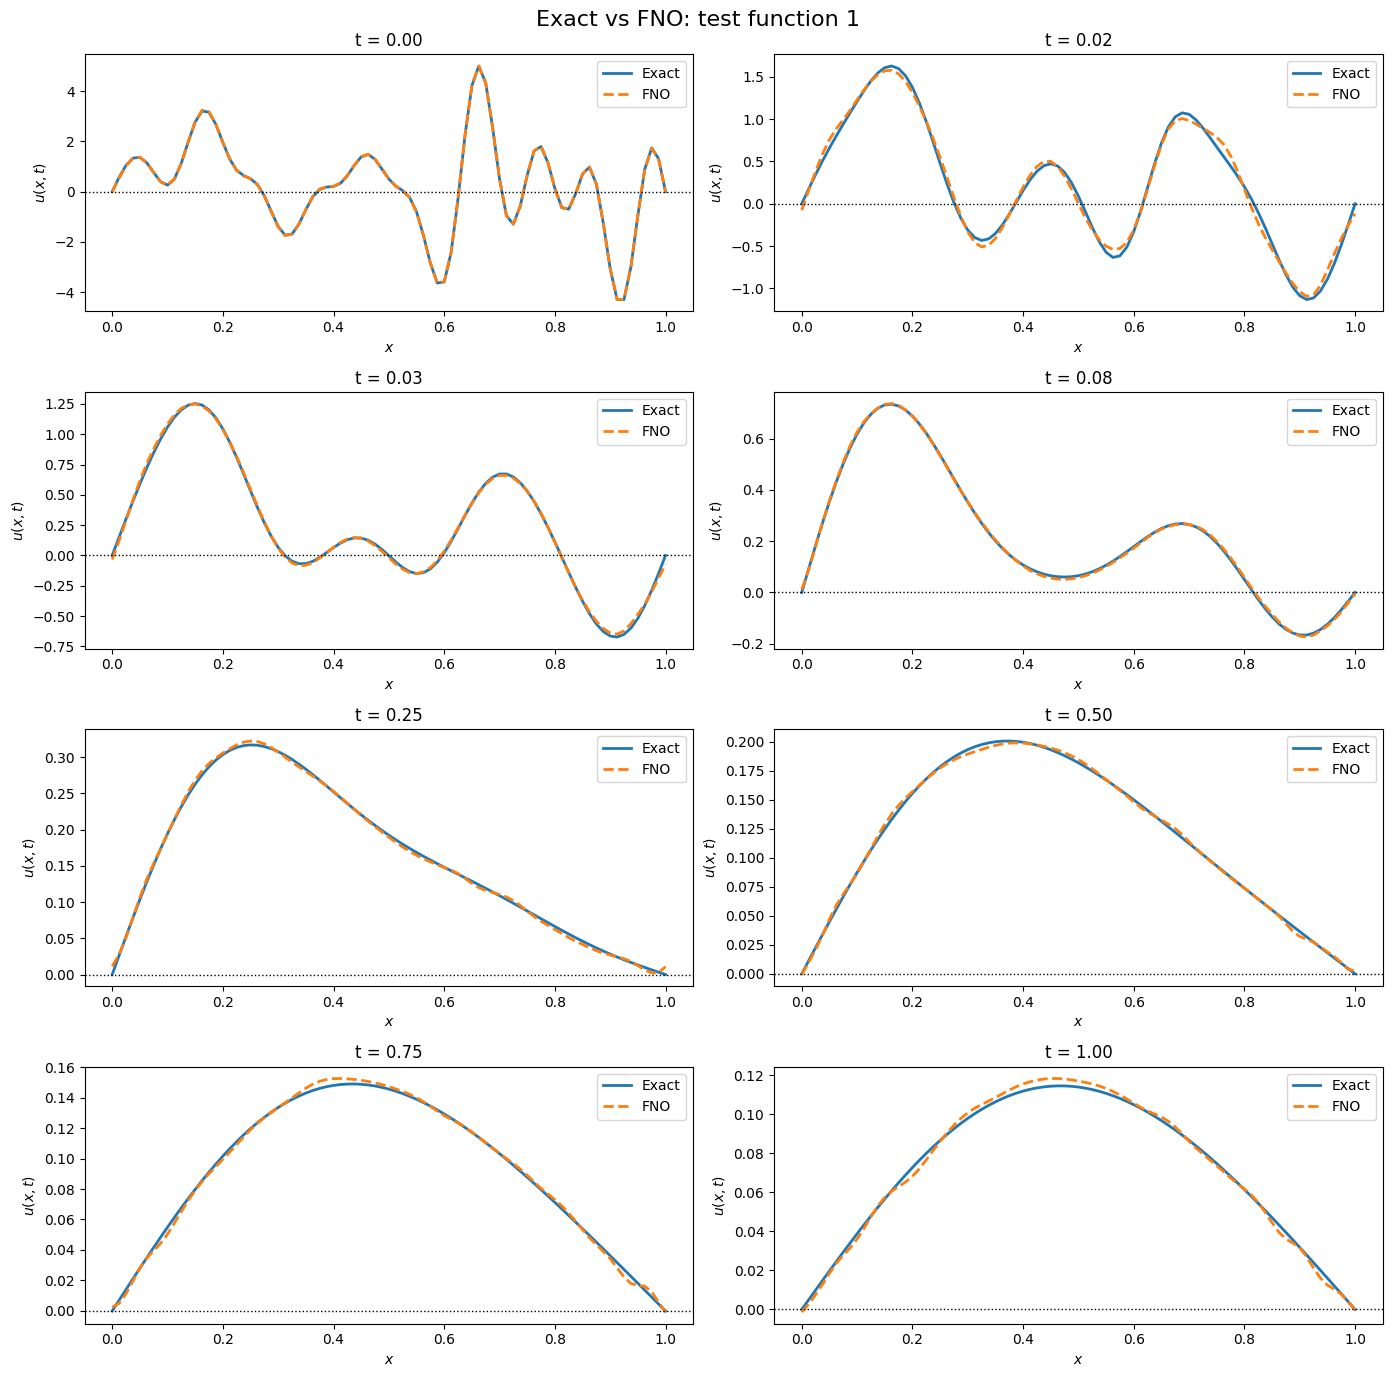

In [24]:
function_index = 1

time_indices = [0,1,2,5,15,30,45,60]


plt.figure(figsize=(14, 14))

for plot_index, time_index in enumerate(time_indices):
    plt.subplot(4, 2, plot_index + 1)

    # Exact solution
    plt.plot(x_arr.detach().cpu().numpy(),u_test[function_index,:,time_index].detach().cpu().numpy(),label="Exact",linewidth=2)

    # FNO prediction
    plt.plot(x_arr.detach().cpu().numpy(),u_test_pred[function_index,:,time_index].detach().cpu().numpy(),label="FNO",linestyle="--",linewidth=2)

    plt.axhline(0.0,color="black",linestyle=":",linewidth=1)

    plt.xlabel(r"$x$")
    plt.ylabel(r"$u(x,t)$")
    plt.title(f"t = {t_arr[time_index].item():.2f}")
    plt.legend()

plt.suptitle(
    f"Exact vs FNO: test function {function_index}",
    fontsize=16
)

plt.tight_layout()
plt.show()

### Remarks.

1. We have successfully implemented an FNO architecture for Heat Equation PDE.

2. We see that there is further scope of improvement. This can be done by :

--> increasing number of epochs for LBFGS optimizer

--> increasing number of training samples

--> increasing the number of non-zero fourier modes in the Fourier Layers of the FNO blocks